# Time-Frequency Representation (TFR) Analysis

## Part of the open_dvm Toolbox

This tutorial demonstrates how to decompose EEG data into time-frequency components using Morlet wavelets, with the open_dvm toolbox. While Event-Related Potentials (ERPs) reveal *when* the brain responds, TFR reveals *which frequencies* carry neural information and how this evolves over time. The tutorial is built around a **lateralization** analysis: comparing contralateral vs. ipsilateral hemisphere activity to reveal how the brain allocates spatial attention.

## Learning Objectives

After completing this tutorial, you will:

- **Compute time-frequency decompositions** — Morlet wavelet-based TFR across a range of frequencies
- **Understand baseline correction choices** — Compare trial-specific, condition-specific, and grand-average methods
- **Analyze lateralized oscillatory effects** — Contralateral vs. ipsilateral hemisphere comparisons
- **Compare experimental conditions** — Task-related differences in oscillatory dynamics

**Prerequisites:** This tutorial requires preprocessed EEG data (see `01_preprocessing.ipynb`).

## Overview

### The Data: Visual Search with Distractor Interference

Participants searched for a target shape while distractors (colored images) were sometimes present. Key features:
- **8 shapes in a circle** at cardinal/diagonal positions
- **Lateralized contrast**: Left vs. right visual field stimuli
- **Task demands**: Passive viewing (localizer) vs. active search (main task)
- **Critical measure**: Alpha band (8-12 Hz) lateralization reveals spatial attention allocation
- **Expected finding**: Contralateral > ipsilateral alpha suppression indicates attention to that field

### Key Steps

1. **Basic TFR computation** — Frequency band decomposition and spectral visualization
2. **Baseline correction methods** — Comparing trial-specific, condition-specific, and grand-average approaches
3. **Lateralized attention analysis** — Visual field effects on hemispheric alpha suppression
4. **Task comparisons** — Differences between passive viewing and active search

For deeper exploration of wavelet parameter choices, Hilbert vs. wavelet decomposition, and multi-subject statistics, see `04_tfr_advanced.ipynb`.

## Section 1: Setup and Configuration

### 1.1 Import Required Libraries

In [1]:
# Enable inline plotting and suppress warnings
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sys
import os
from IPython.display import display

# Add open_dvm to path
sys.path.insert(0, '/Users/dvm/Documents/DvM')

# Import analysis tools
import warnings
warnings.filterwarnings('ignore')

from open_dvm.analysis import TFR
from open_dvm.support.FolderStructure import FolderStructure
from open_dvm.visualization.plot import plot_tfr_timecourse

print("✓ All imports successful!")

✓ All imports successful!


### 1.2 Load Preprocessed Data with Eye-Tracking Quality Control

In [2]:
# ============================================
# Configuration: Change these for your data
# ============================================
project_folder = '/Users/dvm/Library/CloudStorage/OneDrive-VrijeUniversiteitAmsterdam/projects/openDvM'
os.chdir(project_folder)

# Subject number (1-7 in this dataset)
sj = 2

# Eye-tracking quality control
eye_dict = {
    'use_tracker': True,  # Enable eye-tracking exclusion
    'window_oi': (0, 0.3),  # Window: 0-300 ms post-stimulus
    'angle_thresh': 1,  # Threshold: 1 degree visual angle
    'viewing_dist': 70,  # Viewing distance (cm)
    'screen_res': (1920, 1080),  # Screen resolution (pixels)
    'screen_h': 29,  # Screen height (cm)
    'drift_correct': (-0.2, 0)  # Drift correction window
}

# Load preprocessed data
df, epochs = FolderStructure().load_processed_epochs(
    sj, 'ses_01_main', 'main', eye_dict
)

print(f'✓ Subject {sj} data loaded')
print(f'  • {len(epochs)} trials')
print(f'  • {epochs.info["nchan"]} channels')
print(f'  • Sampling rate: {epochs.info["sfreq"]} Hz')

Reading /Users/dvm/Library/CloudStorage/OneDrive-VrijeUniversiteitAmsterdam/projects/openDvM/eeg/processed/sub_02_ses_01_main-epo.fif ...
    Found the data of interest:
        t =    -699.22 ...    1000.00 ms
        0 CTF compensation matrices available
Adding metadata with 19 columns
2902 matching events found
No baseline correction applied
0 projection items activated
Eye channel is not specified in eyedict, using HEOG as default
4 trials missing eyetracking
data (used eog instead)
Eye exclusion info saved in preprocessing file (session 01)
✓ Subject 2 data loaded
  • 2148 trials
  • 39 channels
  • Sampling rate: 512.0 Hz


---

## Section 2: Basic TFR Computation and Frequency Band Analysis

**Research Question**: What does the time-frequency landscape of our EEG data look like? Where do the strongest oscillations occur in time and frequency?

**Approach**: Compute Morlet wavelet-based time-frequency decomposition on localizer task data. Visualize the full spectrogram, then extract individual frequency bands (theta, alpha, beta, gamma) to examine band-specific dynamics.

**Key parameters**:
- **Frequency range**: 4-40 Hz covers theta through gamma bands
- **Cycle range** (3, 10): Lower frequencies use 3 cycles (better time resolution), higher frequencies use 10 cycles (better frequency resolution)
- **Baseline**: -200 to 0 ms (pre-stimulus window)
- **Interpretation**: Negative dB = power suppression (active processing); positive dB = power enhancement

In [3]:
# Initialize TFR analysis with standard parameters
tfr_basic = TFR(
    sj=sj,
    epochs=epochs,
    df=df,
    min_freq=4,          # Start from theta band (4 Hz)
    max_freq=40,         # Up to low gamma (40 Hz)
    num_frex=25,         # 25 frequencies between 4-40 Hz
    cycle_range=(3, 10), # Wavelet cycles: more cycles at higher frequencies
    freq_scaling='log',  # Logarithmic frequency spacing
    baseline=(-0.2, 0),  # Baseline period: -200 to 0 ms pre-stimulus
    base_method='trial_spec',  # Trial-specific baseline correction
    downsample=4         # Downsample by factor of 4
)

print("✓ TFR initialized with standard parameters")
print(f"  • Frequency range: {tfr_basic.min_freq}-{tfr_basic.max_freq} Hz")
print(f"  • Number of frequencies: {tfr_basic.num_frex}")
print(f"  • Cycle range: {tfr_basic.cycle_range}")

✓ TFR initialized with standard parameters
  • Frequency range: 4-40 Hz
  • Number of frequencies: 25
  • Cycle range: (3, 10)


In [4]:
# Compute TFR for localizer task
print('\nComputing time-frequency decomposition...')

tfr_result = tfr_basic.condition_tfrs(
    pos_labels=None,                      # No position-based lateralization for this pass
    cnds={'block_type': ['localizer']},   # Passive-viewing localizer trials only
    elec_oi='all',                        # Average across all electrodes
    window_oi=(-0.2, 0.5)                 # Analysis window: -200 to 500 ms
)

# Extract power data and frequency/time info for later use
power_tfr = tfr_result['localizer'].data  # Shape: (n_channels, n_frequencies, n_times)
times = tfr_result['localizer'].times
freqs = tfr_result['localizer'].freqs

print("✓ TFR computation complete")
print(f"  • Power shape: {power_tfr.shape}")
print(f"    - Channels: {power_tfr.shape[0]}")
print(f"    - Frequencies: {power_tfr.shape[1]}")
print(f"    - Time points: {power_tfr.shape[2]}")


Computing time-frequency decomposition...
No topography info specified. For lateralization analysis, it is assumed as if all stimuli of interest are presented right (i.e., left  hemifield
Decomposing condition 1: localizer 

✓ TFR computation complete of 32 channels
  • Power shape: (32, 25, 90)
    - Channels: 32
    - Frequencies: 25
    - Time points: 90


No conditions specified. Using first condition in tfr
not enough colors specified. Using default colors
Times converted from seconds to milliseconds


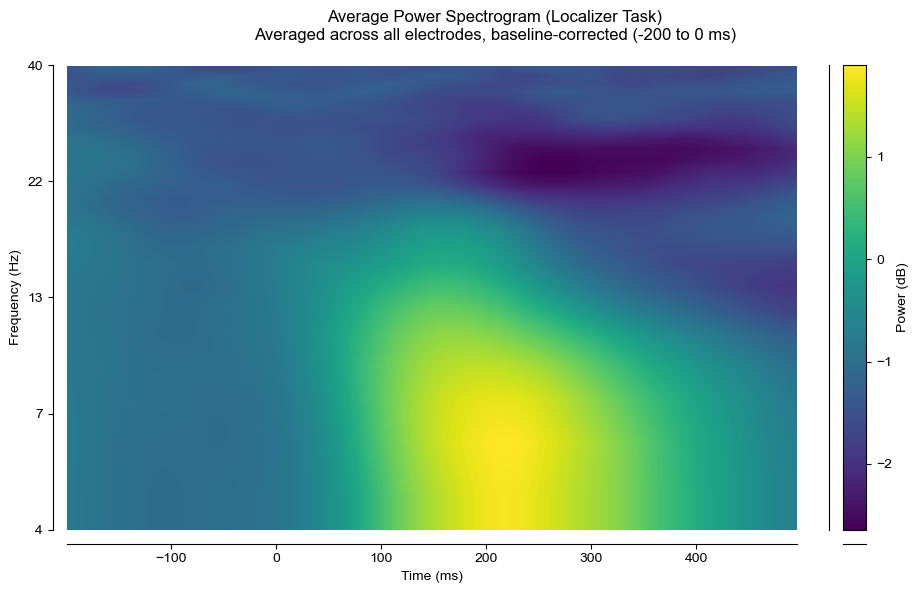

✓ Spectrogram visualization complete
  • Baseline period: -200 to 0 ms (pre-stimulus)
  • Negative dB = power suppression (active processing)
  • Positive dB = power enhancement relative to baseline


In [5]:
# Visualize full spectrogram
plt.figure(figsize=(10, 6))
plot_tfr_timecourse(
    tfr=tfr_result,
    elec_oi=list(tfr_result['localizer'].ch_names),
    timecourse='2d',
    onset_times=[0]
)
plt.suptitle('Average Power Spectrogram (Localizer Task)\nAveraged across all electrodes, baseline-corrected (-200 to 0 ms)')
plt.tight_layout()
display(plt.gcf())
plt.close()

print("✓ Spectrogram visualization complete")
print(f"  • Baseline period: -200 to 0 ms (pre-stimulus)")
print(f"  • Negative dB = power suppression (active processing)")
print(f"  • Positive dB = power enhancement relative to baseline")

In [6]:
# Analyze individual frequency bands
bands = {
    'Theta (4-8 Hz)': (4, 8),
    'Alpha (8-12 Hz)': (8, 12),
    'Beta (15-30 Hz)': (15, 30),
    'Gamma (30-40 Hz)': (30, 40)
}

print("\nFrequency bands:")
for band_name in bands.keys():
    print(f"  • {band_name}")


Frequency bands:
  • Theta (4-8 Hz)
  • Alpha (8-12 Hz)
  • Beta (15-30 Hz)
  • Gamma (30-40 Hz)


No conditions specified. Using first condition in tfr
not enough colors specified. Using default colors
Times converted from seconds to milliseconds
No conditions specified. Using first condition in tfr
not enough colors specified. Using default colors
Times converted from seconds to milliseconds
No conditions specified. Using first condition in tfr
not enough colors specified. Using default colors
Times converted from seconds to milliseconds
No conditions specified. Using first condition in tfr
not enough colors specified. Using default colors
Times converted from seconds to milliseconds


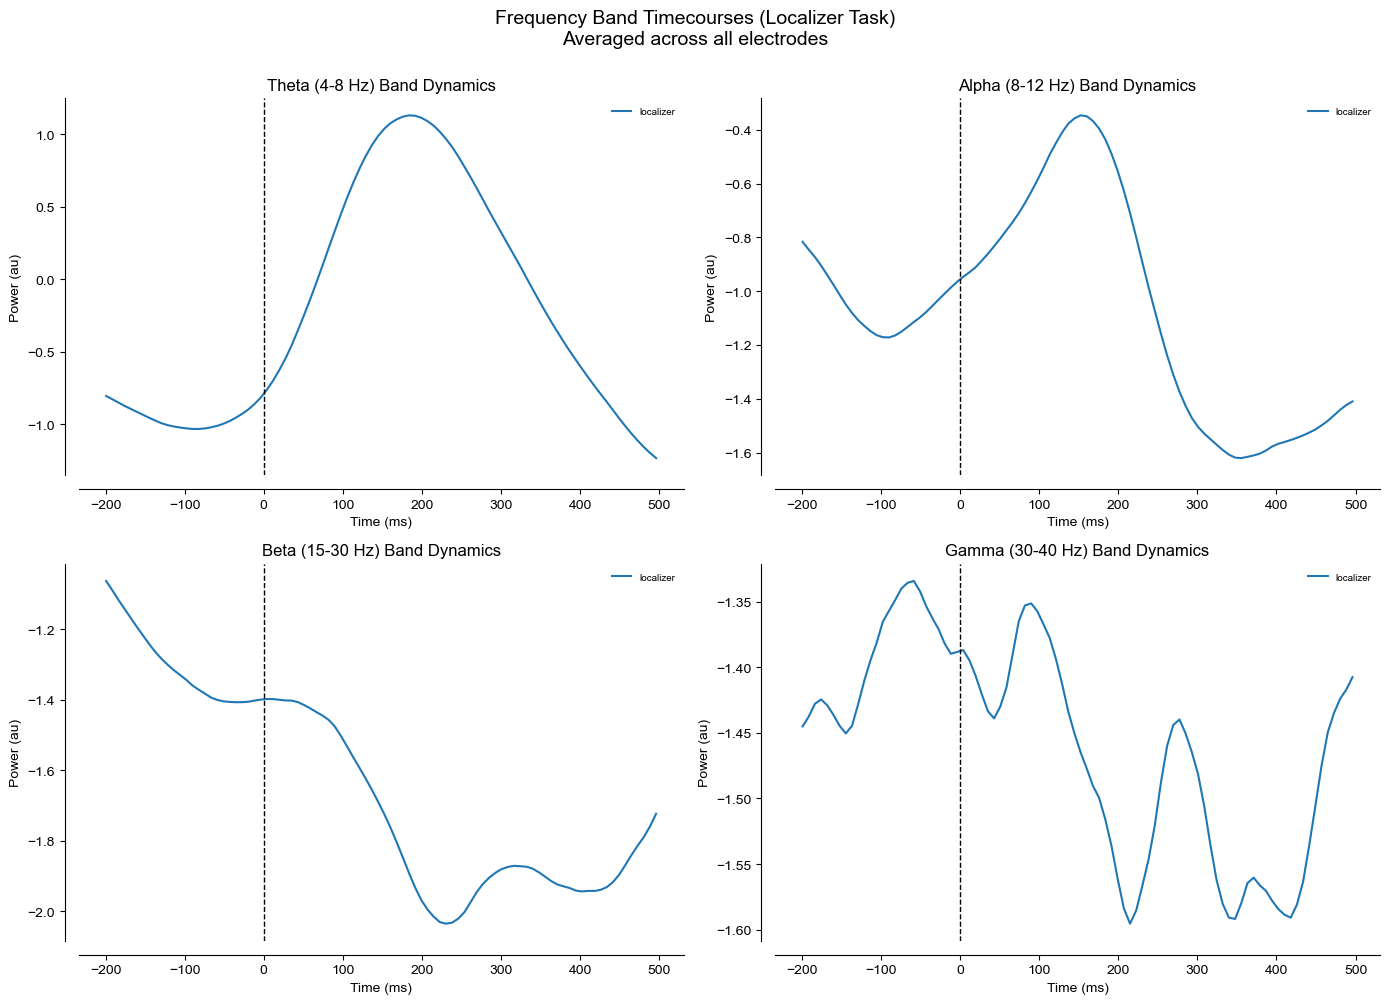

✓ Band timecourse visualization complete


In [7]:
# Plot each frequency band timecourse
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, (band_name, freq_range) in enumerate(bands.items()):
    plt.subplot(2, 2, idx + 1)
    
    plot_tfr_timecourse(
        tfr=tfr_result,
        elec_oi=list(tfr_result['localizer'].ch_names),
        freq_oi=freq_range,  # Extract specific frequency band
        timecourse='1d',      # Plot as 1D timecourse (averaged over frequencies)
        onset_times=[0]
    )
    plt.title(f'{band_name} Band Dynamics', fontsize=12)
    
plt.suptitle('Frequency Band Timecourses (Localizer Task)\nAveraged across all electrodes', 
             fontsize=14, y=1.00)
plt.tight_layout()
display(fig)
plt.close()

print("✓ Band timecourse visualization complete")

---

## Section 3: Baseline Correction Methods

**Research Question**: How does baseline correction method affect TFR interpretation? Are there systematic differences between trial-specific, condition-specific, and grand-average approaches?

**Approach**: Compute the same data with three different baseline methods and compare their effects on power normalization across baseline methods and experimental conditions.

**Baseline methods**:
- **trial_spec** — Baseline corrected per trial before averaging (most conservative)
- **cnd_spec** — Condition-specific baseline (recommended by Cohen 2014)
- **cnd_avg** — Grand-average baseline across all conditions

In [8]:
# Compute TFR with different baseline methods
baseline_methods = ['trial_spec', 'cnd_spec', 'cnd_avg']
tfr_comparison = {method: {} for method in baseline_methods}

print(f'Computing TFR with {len(baseline_methods)} baseline methods for 2 conditions...\n')

for method in baseline_methods:
    print(f'Baseline method: {method.replace("_", " ").title()}')
    
    tfr_temp = TFR(
        sj=sj,
        epochs=epochs,
        df=df,
        min_freq=4,                # Start from theta band (4 Hz)
        max_freq=40,               # Up to low gamma (40 Hz)
        num_frex=25,               # 25 frequencies between 4-40 Hz
        cycle_range=(3, 10),       # Wavelet cycles: more cycles at higher frequencies
        freq_scaling='log',        # Logarithmic frequency spacing
        baseline=(-0.2, 0),        # Baseline period: -200 to 0 ms pre-stimulus
        base_method=method,        # Baseline method under comparison (loop variable)
        downsample=2               # Downsample by factor of 2
    )
    
    # Compute TFR for both conditions
    tfr_result = tfr_temp.condition_tfrs(
        pos_labels=None,                              # No position-based lateralization for this comparison
        cnds={'block_type': ['main', 'localizer']},   # Compare main task vs localizer
        elec_oi=['PO3','PO4','O1','O2','Pz'],         # Occipital electrodes
        window_oi=(-0.2, 0.5),                        # Analysis window: -200 to 500 ms
        f_name=f'baseline_{method}'                   # Save per baseline method for later reload
    )
    
    tfr_comparison[method] = tfr_result

print('\n✓ TFR computation complete')

Computing TFR with 3 baseline methods for 2 conditions...

Baseline method: Trial Spec
No topography info specified. For lateralization analysis, it is assumed as if all stimuli of interest are presented right (i.e., left  hemifield
Decomposing condition 1: main 

Decomposing condition 2: localizer nels

saving tfr for condition: main channels
Overwriting existing file.
saving tfr for condition: localizer
Overwriting existing file.
Baseline method: Cnd Spec
No topography info specified. For lateralization analysis, it is assumed as if all stimuli of interest are presented right (i.e., left  hemifield
Decomposing condition 1: main 

Decomposing condition 2: localizer nels

saving tfr for condition: main channels
Overwriting existing file.
saving tfr for condition: localizer
Overwriting existing file.
Baseline method: Cnd Avg
No topography info specified. For lateralization analysis, it is assumed as if all stimuli of interest are presented right (i.e., left  hemifield
Decomposing condit

No conditions specified. Using first condition in tfr
not enough colors specified. Using default colors
Times converted from seconds to milliseconds
No conditions specified. Using first condition in tfr
not enough colors specified. Using default colors
Times converted from seconds to milliseconds
No conditions specified. Using first condition in tfr
not enough colors specified. Using default colors
Times converted from seconds to milliseconds
No conditions specified. Using first condition in tfr
not enough colors specified. Using default colors
Times converted from seconds to milliseconds
No conditions specified. Using first condition in tfr
not enough colors specified. Using default colors
Times converted from seconds to milliseconds
No conditions specified. Using first condition in tfr
not enough colors specified. Using default colors
Times converted from seconds to milliseconds


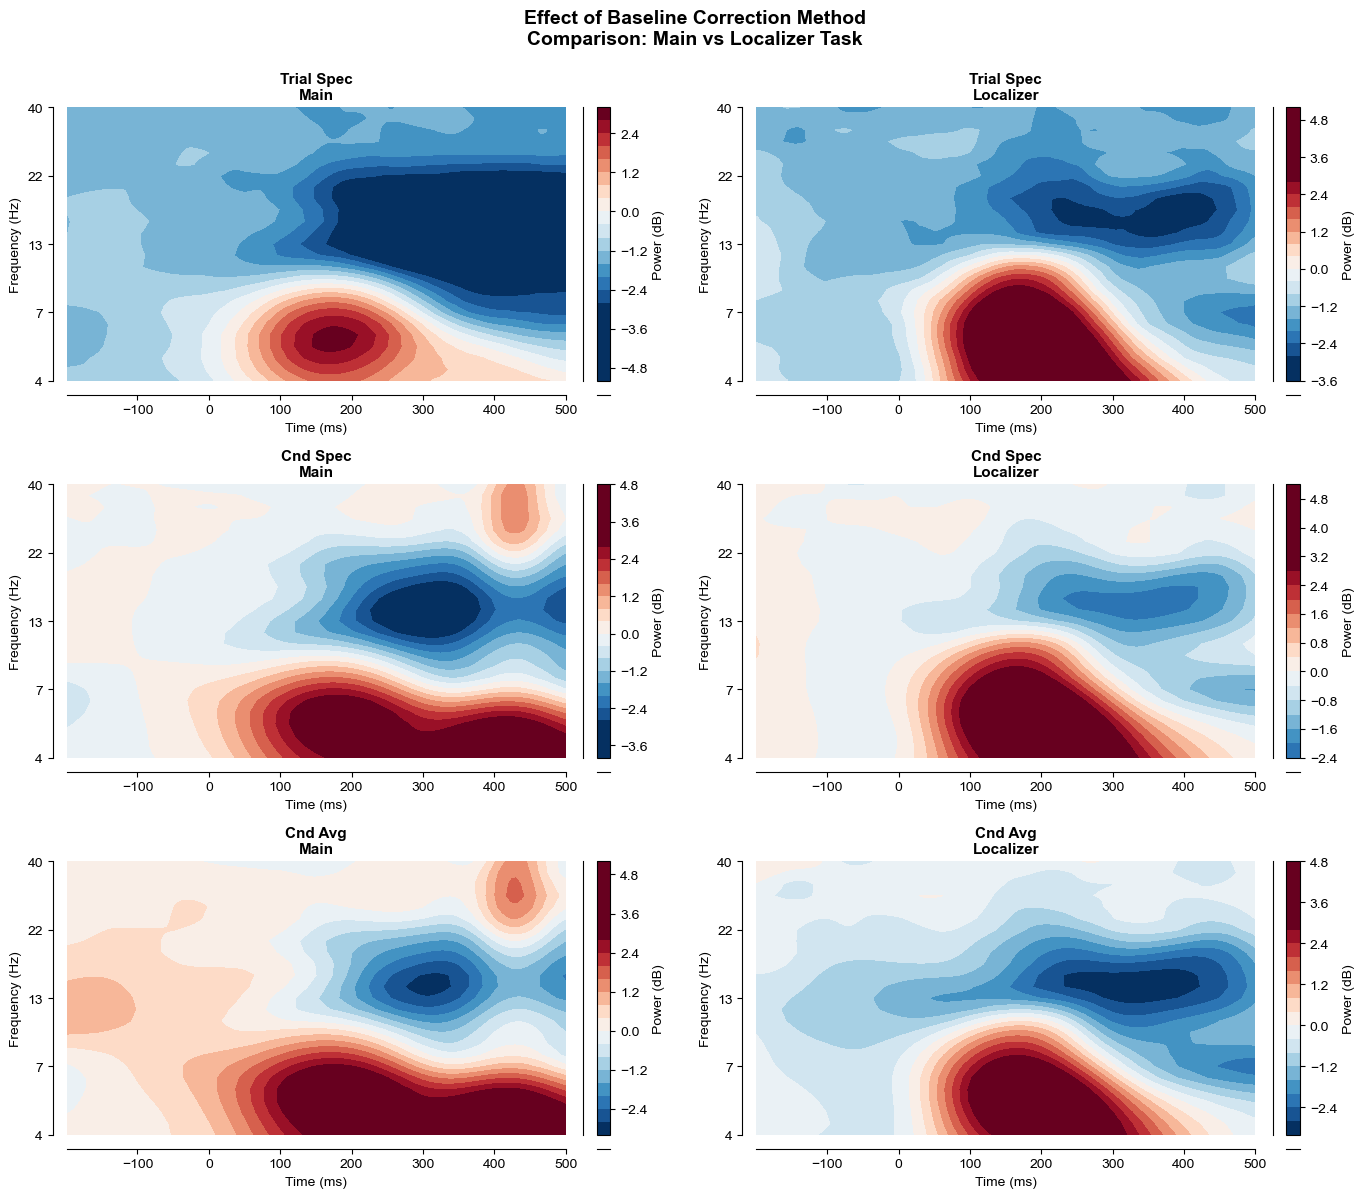


✓ Baseline method comparison complete

Key observations:
• Within columns (same condition): How does baseline method affect absolute scaling?
• Within rows (same method): How do conditions differ spectrally?
• trial_spec: Most conservative, removes trial-specific baseline variability
• cnd_spec: Recommended approach; reveals condition-specific differences clearly
• cnd_avg: Grand-average baseline; assumes common baseline across conditions


In [ ]:
# Visualize: Baseline methods × Conditions
conditions_to_compare = ['main', 'localizer']
method_labels = ['Trial Spec', 'Cnd Spec', 'Cnd Avg']

fig, axes = plt.subplots(len(baseline_methods), len(conditions_to_compare), 
                          figsize=(14, 12))

for method_idx, method in enumerate(baseline_methods):
    for cond_idx, cnd in enumerate(conditions_to_compare):
        plt.sca(axes[method_idx, cond_idx])
        
        # Prepare data for this condition
        tfr_data = {cnd: tfr_comparison[method][cnd]}
        
        # Use plot_tfr_timecourse with filled contours
        plot_tfr_timecourse(
            tfr=tfr_data,
            elec_oi=['PO3', 'PO4', 'O1', 'O2', 'Pz'],
            timecourse='2d',
            contour=True,
            levels=20,
            cmap='RdBu_r',
            vmin=-3,
            vmax=3,
            onset_times=[0]
        )
        
        # Customize title
        title = f'{method_labels[method_idx]}\n{cnd.title()}'
        plt.title(title, fontsize=11, fontweight='bold')

plt.suptitle('Effect of Baseline Correction Method\nComparison: Main vs Localizer Task', 
             fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
display(fig)
plt.close()

print("\n✓ Baseline method comparison complete\n")
print("Key observations:")
print("• Within columns (same condition): How does baseline method affect absolute scaling?")
print("• Within rows (same method): How do conditions differ spectrally?")
print("• trial_spec: Most conservative, removes trial-specific baseline variability")
print("• cnd_spec: Reveals condition-specific differences clearly")
print("• cnd_avg: Grand-average baseline; assumes common baseline across conditions")

---

## Section 4: Lateralized Attention Analysis

**Research Question**: How does visual attention to left vs. right visual fields affect hemispheric alpha activity?

**Key Concept**: Visual attention produces a robust lateralization effect where the hemisphere *contralateral* (opposite) to the attended visual field shows stronger alpha suppression than the ipsilateral hemisphere. This is a fundamental finding in attention neuroscience.

**Analysis setup**:
- **Spatial contrast**: Left visual field (RVF → left hemisphere) vs. right visual field (LVF → right hemisphere)
- **Topo flip**: Normalize left-field distractors to right hemisphere for direct comparison
- **Metric**: Contralateral-minus-ipsilateral difference reveals pure attention-related lateralization
- **Expected finding**: Red regions (positive values) show contralateral hemisphere advantage

In [10]:
# Compute lateralized TFR for distractor processing
tfr_lateral = TFR(
    sj=sj,
    epochs=epochs,
    df=df,
    min_freq=4,                # Start from theta band (4 Hz)
    max_freq=40,               # Up to low gamma (40 Hz)
    num_frex=25,               # 25 frequencies between 4-40 Hz
    cycle_range=(3, 10),       # Wavelet cycles: more cycles at higher frequencies
    freq_scaling='log',        # Logarithmic frequency spacing
    baseline=(-0.2, 0),        # Baseline period: -200 to 0 ms pre-stimulus
    base_method='trial_spec',  # Trial-specific baseline correction
    downsample=2               # Downsample by factor of 2
)

tfr_result = tfr_lateral.condition_tfrs(
    pos_labels=dict(img_loc=[2, 6]),               # Left (2) vs right (6) visual field
    cnds={'distractor_presence': ['present']},     # Distractor-present trials
    elec_oi=['PO3','PO4','O1','O2','P7','P8'],     # Occipital electrodes
    topo_flip=dict(img_loc=[2]),                   # Flip left-field distractors for comparison
    spatial_restriction=dict(target_loc=[0,4,8]),  # Restrict to specific target positions
    window_oi=(-0.2, 0.5),                         # Analysis window: -200 to 500 ms
    excl_factor=dict(block_type='localizer'),      # Main task only
    f_name='distractor_lateralization'             # Analysis identifier for saved output
)

print("✓ Lateralized TFR computation complete")
print(f"  • Data structure: {list(tfr_result.keys())}")
print(f"  • Shape: {tfr_result['present'].data.shape}")

Trial exclusion: no trials selected that matched specified criteria
No flip dictionary specified. Creating flip based on epochs layout. Assumes that odd electrodes are left and even electrodes are right
flipping topography
Decomposing condition 1: present 

saving tfr for condition: presentannels
Overwriting existing file.
✓ Lateralized TFR computation complete
  • Data structure: ['present']
  • Shape: (6, 25, 180)


No conditions specified. Using first condition in tfr
not enough colors specified. Using default colors
Times converted from seconds to milliseconds


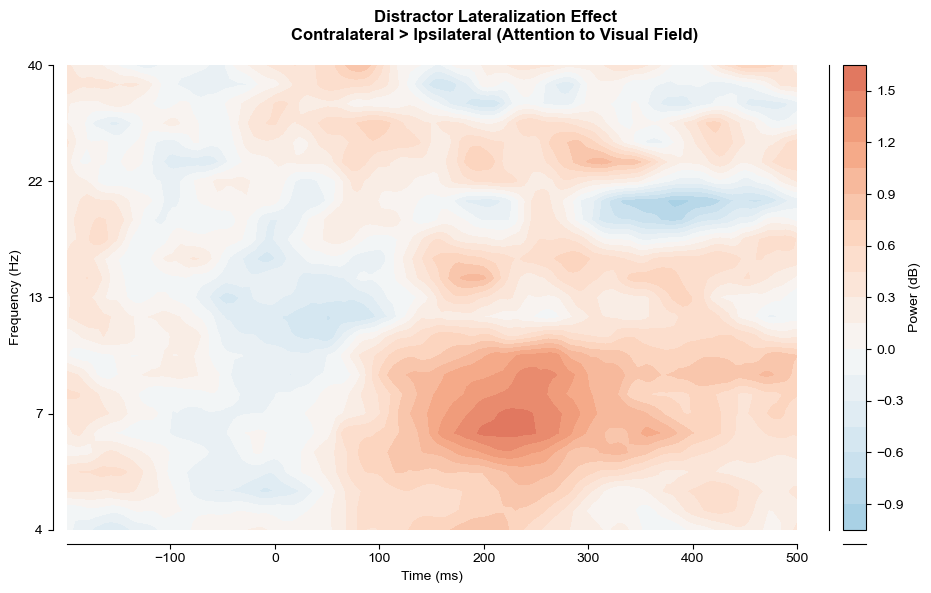


✓ Lateralization visualization complete
  • Red regions: Contralateral hemisphere dominance (attention effect)
  • Blue regions: Ipsilateral activity
  • Key band: Alpha (8-12 Hz) shows strongest contralateral suppression


In [11]:
# Visualize lateralization effect
plt.close('all')

tfr_present = {'distractor_present': tfr_result['present']}

fig = plt.figure(figsize=(10, 6))

plot_tfr_timecourse(
    tfr=tfr_present,
    elec_oi=[['PO3', 'O1'], ['PO4', 'O2']],  # [left hemi, right hemi]
    timecourse='2d',
    contour=True,
    lateralized=True,
    levels=20,
    cmap='RdBu_r',
    vmin=-3,
    vmax=3,
    onset_times=[0]
)

plt.suptitle('Distractor Lateralization Effect\nContralateral > Ipsilateral (Attention to Visual Field)', 
             fontsize=12, fontweight='bold', y=0.98)
plt.tight_layout()
display(fig)
plt.close()

print("\n✓ Lateralization visualization complete")
print("  • Red regions: Contralateral hemisphere dominance (attention effect)")
print("  • Blue regions: Ipsilateral activity")
print("  • Key band: Alpha (8-12 Hz) shows strongest contralateral suppression")

---

## Section 5: Task-Related Condition Comparisons

**Research Question**: Do different experimental conditions show distinct time-frequency signatures? How does task context (passive viewing vs. active search) modulate oscillatory dynamics?

**Approach**: Compare TFR activity between the localizer task (passive viewing of repeated images) and main task (active search for targets while ignoring distractors).

In [12]:
# Compute TFR for both conditions
print('Computing TFR by condition...')

tfr_standard = TFR(
    sj=sj,
    epochs=epochs,
    df=df,
    min_freq=4,                # Start from theta band (4 Hz)
    max_freq=40,               # Up to low gamma (40 Hz)
    num_frex=25,               # 25 frequencies between 4-40 Hz
    cycle_range=(3, 10),       # Wavelet cycles: more cycles at higher frequencies
    freq_scaling='log',        # Logarithmic frequency spacing
    baseline=(-0.2, 0),        # Baseline period: -200 to 0 ms pre-stimulus
    base_method='trial_spec',  # Trial-specific baseline correction
    downsample=2               # Downsample by factor of 2
)

tfr_by_cond = tfr_standard.condition_tfrs(
    pos_labels=None,                             # No position-based lateralization for this comparison
    cnds={'block_type': ['localizer', 'main']},  # Compare localizer vs main task
    elec_oi='all',                               # Average across all electrodes
    window_oi=(-0.2, 0.5),                       # Analysis window: -200 to 500 ms
    f_name='tutorial'                            # Analysis identifier for saved output
)

print(f"✓ Condition TFR computation complete")
print(f"  • Localizer shape: {tfr_by_cond['localizer'].data.shape}")
print(f"  • Main task shape: {tfr_by_cond['main'].data.shape}")

Computing TFR by condition...
No topography info specified. For lateralization analysis, it is assumed as if all stimuli of interest are presented right (i.e., left  hemifield
Decomposing condition 1: localizer 

Decomposing condition 2: main 32 channels

saving tfr for condition: localizerannels
saving tfr for condition: main
✓ Condition TFR computation complete
  • Localizer shape: (32, 25, 180)
  • Main task shape: (32, 25, 180)


In [13]:
# Visualize condition comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Extract power data
localizer_power = tfr_by_cond['localizer'].data
main_power = tfr_by_cond['main'].data

# Average across channels
localizer_avg = localizer_power.mean(axis=0)
main_avg = main_power.mean(axis=0)
diff = main_avg - localizer_avg

vmin, vmax = -3, 3

# Localizer
im1 = axes[0, 0].contourf(times, freqs, localizer_avg, levels=20, cmap='viridis', vmin=vmin, vmax=vmax)
axes[0, 0].set_title('Localizer Task')
axes[0, 0].set_ylabel('Frequency (Hz)')
axes[0, 0].axvline(0, color='white', linestyle='--', linewidth=2)
plt.colorbar(im1, ax=axes[0, 0], label='Power (dB)')

# Main task
im2 = axes[0, 1].contourf(times, freqs, main_avg, levels=20, cmap='viridis', vmin=vmin, vmax=vmax)
axes[0, 1].set_title('Main Task')
axes[0, 1].axvline(0, color='white', linestyle='--', linewidth=2)
plt.colorbar(im2, ax=axes[0, 1], label='Power (dB)')

# Difference
im3 = axes[1, 0].contourf(times, freqs, diff, levels=20, cmap='RdBu_r', vmin=-3, vmax=3)
axes[1, 0].set_title('Difference (Main - Localizer)')
axes[1, 0].set_xlabel('Time (ms)')
axes[1, 0].set_ylabel('Frequency (Hz)')
axes[1, 0].axvline(0, color='black', linestyle='--', linewidth=2)
plt.colorbar(im3, ax=axes[1, 0], label='Power difference (dB)')

# Alpha band timecourse
freq_mask_alpha = (freqs >= 8) & (freqs <= 12)
alpha_localizer = localizer_avg[freq_mask_alpha, :].mean(axis=0)
alpha_main = main_avg[freq_mask_alpha, :].mean(axis=0)

axes[1, 1].plot(times, alpha_localizer, linewidth=2.5, label='Localizer', color='#1f77b4')
axes[1, 1].plot(times, alpha_main, linewidth=2.5, label='Main task', color='#ff7f0e')
axes[1, 1].axvline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
axes[1, 1].axhline(0, color='gray', linestyle=':', linewidth=1, alpha=0.5)
axes[1, 1].set_xlabel('Time (ms)')
axes[1, 1].set_ylabel('Alpha Power (dB)')
axes[1, 1].set_title('Alpha Band (8-12 Hz) Timecourse')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
display(fig)
plt.close()

print("✓ Condition comparison visualization complete")

TypeError: Length of x (90) must match number of columns in z (180)

---

## Section 6: Summary and Next Steps

### What You've Learned

1. **TFR fundamentals** — Morlet wavelet decomposition reveals oscillatory dynamics across time and frequency
2. **Frequency bands** — Different bands (theta, alpha, beta, gamma) carry distinct neural information
3. **Baseline correction** — Method choice significantly impacts power scaling; trial-specific and condition-specific approaches recommended
4. **Lateralization analysis** — Contralateral > ipsilateral differences reveal hemispheric specialization for spatial attention
5. **Condition effects** — Task context modulates oscillatory patterns; passive viewing vs. active search show different signatures

### Key Findings from This Dataset

- **Alpha suppression** (8-12 Hz, 150-400 ms) — Strongest over occipital regions, contralateral to attended field
- **Distractor effects** — Distractors reduce alpha lateralization, indicating attention capture
- **Task differences** — Main task shows stronger alpha suppression than passive localizer
- **Baseline robustness** — Lateralization patterns stable across baseline methods (but absolute power varies)

### Best Practices

✅ **Document parameter choices** — Report cycle ranges, frequency bounds, baseline windows  
✅ **Validate with multiple baselines** — Verify conclusions aren't artifacts of normalization  
✅ **Use lateralization for robustness** — Contralateral-ipsilateral differences reduce individual variability  
✅ **Choose cycles wisely** — Match temporal-frequency resolution to your research question  
✅ **Visualize with contours** — Filled contours better reveal spectral patterns than heatmaps alone  

### Next Steps

1. **Wavelet parameter optimization and multi-subject statistics** → See `04_tfr_advanced.ipynb`
2. **Multivariate Analysis** → See `05_bdm_decoding.ipynb` for classification/decoding, including TFR-based features
3. **Spatial Encoding** → See `07_ctf_analysis.ipynb` for channel tuning functions (inverted encoding model)
4. Test **frequency-specific hypotheses**: Do specific bands predict behavior?